
# ⚽ FIFA World Cup Intelligence & Prediction System

## 1. Introduction

Football is the world's most popular sport, with international matches being played for more than a century. This project explores historical international football results to understand team performance, tournament trends, scoring patterns, and other key insights.

In later phases, the project will also include predictive modeling to forecast match outcomes using historical data.

This notebook focuses only on the first step: understanding and exploring the dataset.

---

## 2. Dataset Information

**Dataset:** International Football Results (1872–2017)

The dataset contains records of international football matches played between national teams from 1872 onwards.

It includes information such as:

- Teams involved in each match
- Match scores
- Tournament details
- Match location
- Neutral-ground information

### Files Used

- `results.csv` — Match-level results
- `goalscorers.csv` — Goal scorer information
- `shootouts.csv` — Penalty shootout results

---

## 3. Main Columns in `results.csv`

| Column | Description |
|----------|-------------|
| date | Match date |
| home_team | Home team |
| away_team | Away team |
| home_score | Goals scored by the home team |
| away_score | Goals scored by the away team |
| tournament | Tournament or competition name |
| city | Host city |
| country | Host country |
| neutral | Whether the match was played at a neutral venue |

---

## 4. Project Objectives

The overall project aims to answer questions such as:

- Which national teams have been the most successful over time?
- How has international football evolved over the years?
- Which tournaments are played most frequently?
- What are the common goal-scoring patterns?
- Does playing at home provide a measurable advantage?
- Can historical data be used to predict future match outcomes?

---

## 5. Scope of This Notebook

In this notebook, we will:

- Load and inspect the dataset
- Understand its structure and contents
- Explore key statistics
- Identify initial patterns and trends
- Examine data quality issues

No data cleaning, feature engineering, or machine learning will be performed in this phase.


### 1: Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Settings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

sns.set_theme(style='whitegrid')

print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2: Load Data

In [2]:
# Load the main results file
df = pd.read_csv('../data/results.csv')

# Parse date column
df['date'] = pd.to_datetime(df['date'])

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')


Dataset loaded: 49477 rows, 9 columns


In [3]:
# Random sample
print('Random sample (10 rows):')
df.sample(10, random_state=42)

Random sample (10 rows):


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
45400,2022-06-13,Guatemala,Dominican Republic,2.00,0.00,CONCACAF Nations League,Guatemala City,Guatemala,False
2791,1945-10-21,Sweden,Norway,10.00,0.00,Friendly,Solna,Sweden,False
46584,2023-10-16,Botswana,Eswatini,2.00,1.00,Friendly,Lobatse,Botswana,False
199,1907-02-23,Northern Ireland,Wales,2.00,3.00,British Home Championship,Belfast,Ireland,False
45518,2022-09-23,Saudi Arabia,Ecuador,0.00,0.00,Friendly,Murcia,Spain,True
6556,1966-02-27,Niger,DR Congo,2.00,1.00,Friendly,Niamey,Niger,False
7100,1967-08-13,India,Western Australia,3.00,1.00,Merdeka Tournament,Kuala Lumpur,Malaysia,True
36297,2012-10-12,Czech Republic,Malta,3.00,1.00,FIFA World Cup qualification,Plzeň,Czech Republic,False
25283,2001-03-07,Lebanon,Syria,2.00,2.00,Friendly,Tripoli,Lebanon,False
3751,1953-04-15,Northern Ireland,Wales,2.00,3.00,British Home Championship,Belfast,Northern Ireland,False



### 3: Dataset Overview

In [4]:
# Professional summary table
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Unique Values': df.nunique().values
})

summary['Null %'] = (summary['Null Count'] / len(df) * 100).round(2)
summary = summary.reset_index(drop=True)
summary

,Column,Data Type,Non-Null Count,Null Count,Unique Values,Null %
0,date,datetime64[ns],49477,0,16471,0.00
1,home_team,object,49477,0,327,0.00
2,away_team,object,49477,0,321,0.00
3,home_score,float64,49425,52,26,0.11
4,away_score,float64,49425,52,22,0.11
5,tournament,object,49477,0,200,0.00
6,city,object,49477,0,2089,0.00
7,country,object,49477,0,269,0.00
8,neutral,bool,49477,0,2,0.00



### 4: Data Quality Assessment

In [5]:
# --- Duplicate Rows ---
duplicates = df.duplicated().sum()
print(f'Duplicate rows : {duplicates}')

Duplicate rows : 0


In [6]:
# Check score ranges for any obvious anomalies
print('Score range summary:')
df[['home_score', 'away_score']].describe()

Score range summary:


,home_score,away_score
count,49425.00,49425.00
mean,1.76,1.18
std,1.77,1.40
min,0.00,0.00
25%,1.00,0.00
50%,1.00,1.00
75%,2.00,2.00
max,31.00,21.00



### 5: Univariate Analysis

In [7]:
# --- Q1: Total matches ---
total_matches = len(df)
print(f'Total matches in dataset: {total_matches}')

Total matches in dataset: 49477


In [8]:
# --- Q2: Dataset time range ---
print(f'Earliest match : {df["date"].min().date()}')
print(f'Latest match   : {df["date"].max().date()}')
print(f'Span           : {df["date"].max().year - df["date"].min().year} years')

Earliest match : 1872-11-30
Latest match   : 2026-06-27
Span           : 154 years


In [9]:
# --- Q3: Unique countries ---
all_teams = pd.concat([df['home_team'], df['away_team']])
unique_countries = all_teams.nunique()
print(f'Unique countries/teams: {unique_countries}')

Unique countries/teams: 336


Unique tournaments: 200

Top 15 most frequent tournaments:
tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Name: count, dtype: int64


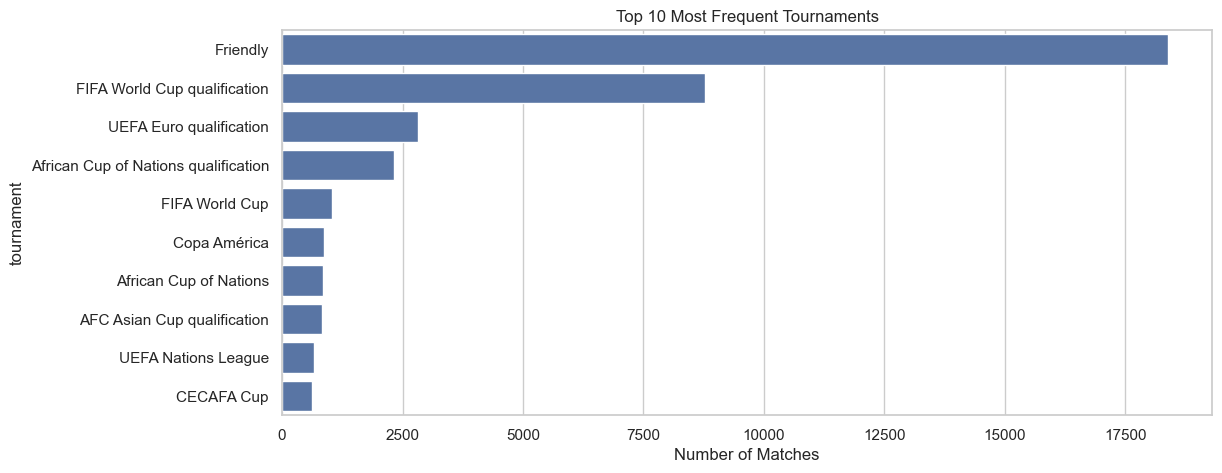

In [10]:
# --- Q4 & Q5: Tournaments ---
unique_tournaments = df['tournament'].nunique()
print(f'Unique tournaments: {unique_tournaments}')

print('\nTop 15 most frequent tournaments:')
tournament_counts = df['tournament'].value_counts().head(15)
print(tournament_counts)

# Plot 
top10_tournaments = df['tournament'].value_counts().head(10)

sns.barplot(
    x=top10_tournaments.values,
    y=top10_tournaments.index
)

plt.title('Top 10 Most Frequent Tournaments')
plt.xlabel('Number of Matches')
plt.show()

In [11]:
# --- Q6: Most frequently appearing countries ---
team_counts = all_teams.value_counts().head(15).reset_index()
print(team_counts.columns)
fig = px.bar(
    team_counts,
    x='count',
    y='index',
    text='count',
    title='Top 15 Countries by Total Appearances'
)
fig.show()

Index(['index', 'count'], dtype='object')



### 6: Temporal Analysis

In [12]:
# Matches per year
df['year'] = df['date'].dt.year
matches_per_year = df.groupby('year').size().reset_index(name="matches")
print(matches_per_year.tail())

# Plot 
fig = px.line(
    matches_per_year,
    x='year',
    y='matches',
    title='Matches Played Per Year'
)
fig.show()


     year  matches
150  2022      970
151  2023     1054
152  2024     1231
153  2025     1002
154  2026      383


In [13]:
# Matches per decade
df['decade'] = (df['year'] // 10) * 10
matches_per_decade = df.groupby('decade').size().reset_index(name='matches')

# Plot 
fig = px.line(
    matches_per_decade,
    x='decade',
    y='matches',
    title='Matches Played Per Decade'
)
fig.show()




### 7: Goal Scoring Analysis

In [14]:
# Drop rows with missing scores for this section
df = df.dropna(subset=['home_score', 'away_score'])
df['total_goals'] = df['home_score'] + df['away_score']

print('Goal scoring summary:')
print(df[['home_score', 'away_score', 'total_goals']].describe())

Goal scoring summary:
       home_score  away_score  total_goals
count    49425.00    49425.00     49425.00
mean         1.76        1.18         2.94
std          1.77        1.40         2.10
min          0.00        0.00         0.00
25%          1.00        0.00         1.00
50%          1.00        1.00         3.00
75%          2.00        2.00         4.00
max         31.00       21.00        31.00


In [15]:
# Top Goal Scoring Countries
home_goals = df.groupby('home_team')['home_score'].sum()
away_goals = df.groupby('away_team')['away_score'].sum()

goals_scored = home_goals.add(away_goals, fill_value=0).rename('total_goals_scored')

home_conceded = df.groupby('home_team')['away_score'].sum()
away_conceded = df.groupby('away_team')['home_score'].sum()

goals_conceded = home_conceded.add(away_conceded, fill_value=0).rename('total_goals_conceded')

team_goal_stats = pd.DataFrame({
    'total_goals_scored': goals_scored,
    'total_goals_conceded': goals_conceded, 
}).fillna(0).astype(int)

# team_goal_stats = team_goal_stats.sort_values('total_goals_scored', ascending=False)
# team_goal_stats.head(20)

In [16]:
# Teams scoring most goals 
team_goal_stats["total_goals_scored"].sort_values(ascending=False).reset_index().head(10)

,index,total_goals_scored
0,England,2381
1,Germany,2327
2,Brazil,2306
3,Sweden,2176
4,Argentina,2031
5,Hungary,2011
6,Netherlands,1843
7,South Korea,1794
8,Mexico,1769
9,France,1718


In [17]:
# Teams conceding most goals 
team_goal_stats["total_goals_conceded"].sort_values(ascending=False).reset_index().head(10)

,index,total_goals_conceded
0,Finland,1675
1,Hungary,1483
2,Switzerland,1446
3,Sweden,1422
4,Norway,1417
5,Austria,1316
6,Northern Ireland,1296
7,Belgium,1291
8,Thailand,1281
9,Singapore,1269


In [18]:
# Average goals
avg_home = df['home_score'].mean()
avg_away = df['away_score'].mean()
avg_total = df['total_goals'].mean()

print(f'Avg home goals  : {avg_home:.2f}')
print(f'Avg away goals  : {avg_away:.2f}')
print(f'Avg total goals : {avg_total:.2f}')

Avg home goals  : 1.76
Avg away goals  : 1.18
Avg total goals : 2.94


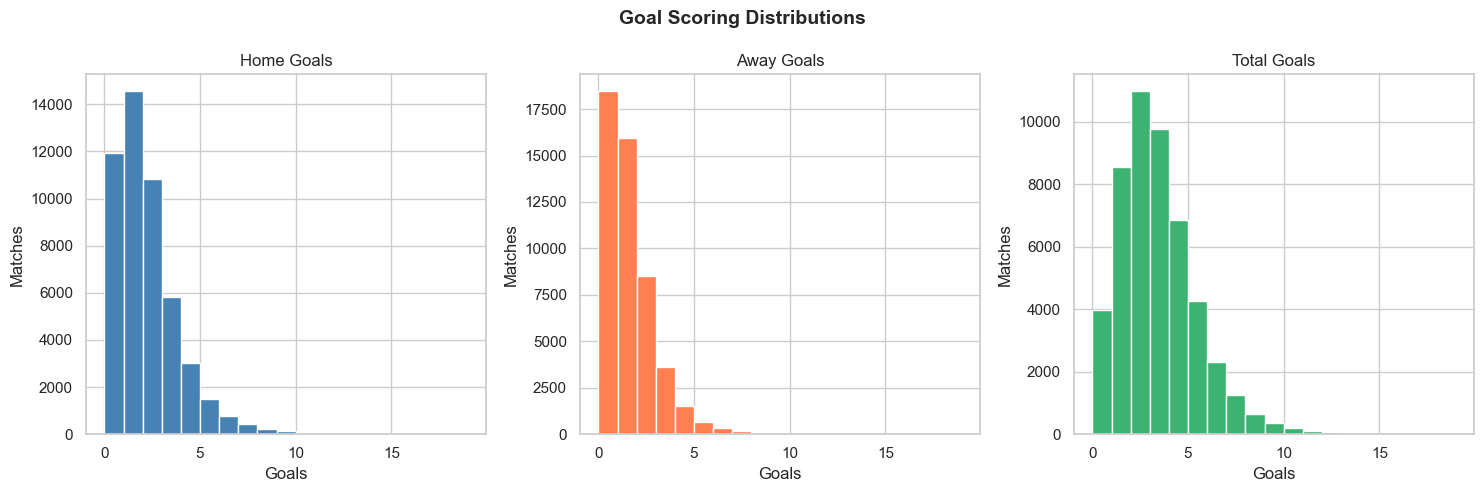

In [19]:
# Histograms — home, away, total goals 
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 5))

ax0.hist(df['home_score'], bins=range(0, 20), color='steelblue')
ax0.set_title('Home Goals')
ax0.set_xlabel('Goals')
ax0.set_ylabel('Matches')

ax1.hist(df['away_score'], bins=range(0, 20), color='coral')
ax1.set_title('Away Goals')
ax1.set_xlabel('Goals')
ax1.set_ylabel('Matches')

ax2.hist(df['total_goals'], bins=range(0, 20), color='mediumseagreen')
ax2.set_title('Total Goals')
ax2.set_xlabel('Goals')
ax2.set_ylabel('Matches')

plt.suptitle('Goal Scoring Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


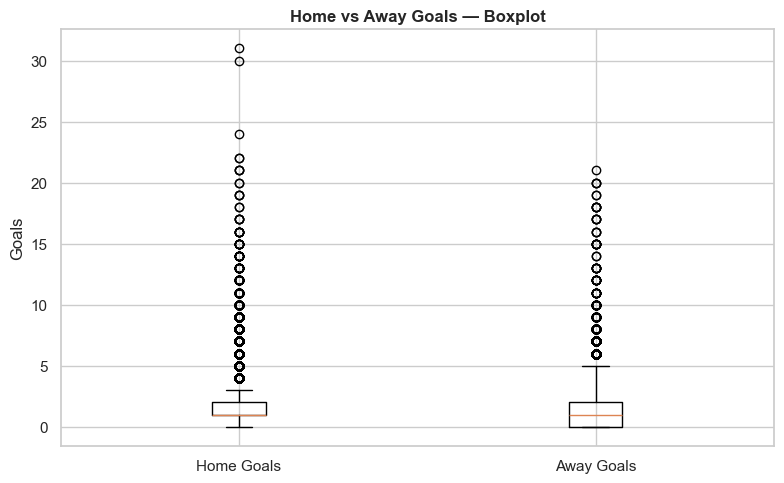

In [20]:
# Boxplot — home vs away goals 

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([
    df['home_score'], df['away_score']
    ])
ax.set_title('Home vs Away Goals — Boxplot',fontweight='bold')
ax.set_xticklabels(['Home Goals', 'Away Goals'])
ax.set_ylabel('Goals')
plt.tight_layout()
plt.show()

In [21]:
# Highest scoring matches
print('Top 10 highest scoring matches:')
df.nlargest(10, 'total_goals')[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'total_goals', 'tournament']]

Top 10 highest scoring matches:


,date,home_team,away_team,home_score,away_score,total_goals,tournament
25425,2001-04-11,Australia,American Samoa,31.00,0.00,31.00,FIFA World Cup qualification
8551,1971-09-13,Tahiti,Cook Islands,30.00,0.00,30.00,South Pacific Games
11916,1979-08-30,Fiji,Kiribati,24.00,0.00,24.00,South Pacific Games
25422,2001-04-09,Australia,Tonga,22.00,0.00,22.00,FIFA World Cup qualification
30518,2006-11-24,Sápmi,Monaco,21.00,1.00,22.00,Viva World Cup
37061,2013-06-24,Provence,Tibet,22.00,0.00,22.00,"International Tournament of Peoples, Cultures ..."
6580,1966-04-03,Libya,Oman,21.00,0.00,21.00,Arab Cup
21957,1997-05-13,Kazakhstan,Guam,20.00,1.00,21.00,East Asian Games
29045,2005-03-11,Guam,North Korea,0.00,21.00,21.00,EAFF Championship
37059,2013-06-23,Quebec,Tibet,21.00,0.00,21.00,"International Tournament of Peoples, Cultures ..."



### 8: Tournament Analysis

In [22]:
# Top 20 tournaments by match count
top20_tournaments = df['tournament'].value_counts().head(20)
print('Top 20 tournaments by number of matches:')
print(top20_tournaments)

Top 20 tournaments by number of matches:
tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            984
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64


In [23]:
# Average goals by tournament
tournament_stats = (
    df
    .groupby("tournament")
    .agg(
        matches = ('total_goals', 'count'),
        avg_goals=('total_goals', 'mean')
    )
    .reset_index()
)

tournament_stats = tournament_stats[tournament_stats['matches'] >= 20]

top_tournaments = (
    tournament_stats
    .sort_values('avg_goals', ascending=False)
    .head(10)
)

print(top_tournaments.columns)

fig = px.bar(
    top_tournaments,
    x='avg_goals',
    y='tournament',
    text='avg_goals',
    title='Top 10 Tournaments by most average goals'
)
fig.show()

Index(['tournament', 'matches', 'avg_goals'], dtype='object')



### 9: Country Participation Analysis

In [24]:
# Home, away, and total appearances per country
home_appearances = df['home_team'].value_counts()
away_appearances = df['away_team'].value_counts()

country_participation = pd.DataFrame({
    'home_appearances': home_appearances,
    'away_appearances': away_appearances
}).fillna(0).astype(int)
country_participation['total_appearances'] = country_participation['home_appearances'] + country_participation['away_appearances']
country_participation = country_participation.sort_values('total_appearances', ascending=False)

print('Top 20 most active countries:')
country_participation.head(20)

Top 20 most active countries:


,home_appearances,away_appearances,total_appearances
Sweden,535,567,1102
England,550,540,1090
Argentina,607,463,1070
Brazil,615,445,1060
Germany,555,477,1032
South Korea,552,456,1008
Hungary,499,507,1006
Mexico,603,401,1004
Uruguay,386,585,971
France,539,397,936


In [25]:
# Home Advantage
home_wins = (df['home_score'] > df['away_score']).sum()
away_wins = (df['home_score'] < df['away_score']).sum()
draws = (df['home_score'] == df['away_score']).sum()

outcome_summary = pd.DataFrame({
    'match_result': ['home_wins', 'away_wins', 'draws'],
    'count': [home_wins, away_wins, draws]
})

fig = px.bar(
    outcome_summary,
    x='match_result',
    y='count',
    text='count',
    title='Match Outcome Distribution',
    color='match_result'
)
fig.show()

In [26]:
# Top 20 Countries by Total Match Appearances
top20 = country_participation.head(20).reset_index()
print(top20.columns)
fig = px.bar(
    top20,
    x='index',
    y='total_appearances',
    title='Top 20 Countries by Total Match Appearances'
)
fig.show()


Index(['index', 'home_appearances', 'away_appearances', 'total_appearances'], dtype='object')


In [28]:
df.isnull().sum()
df.to_csv("../data/clean_results.csv", index=False)

## Key Insights

- The dataset contains over 40,000 international football matches spanning more than 140 years.
- Match volume has increased significantly over time as international football expanded globally.
- Friendly matches make up a large portion of the dataset.
- Home teams score slightly more goals than away teams, suggesting a home advantage.
- A few extreme high-scoring matches exist but are rare.

---

## Conclusion

This phase focused on understanding the dataset and identifying its main characteristics.

Key observations:

- The dataset covers a long history of international football.
- Data quality is generally good, with only a small number of missing values.
- Friendly matches may need separate treatment in future analysis.
- Historical country name changes may require standardization.

### Next Steps

- Clean and prepare the data.
- Create new features such as match outcome and goal difference.
- Analyze country-level performance.
- Explore World Cup-specific trends.
- Build predictive models for match outcomes.
